In [ ]:
# 1. Dataset Selection:
#    My data set is an IMDB Horror Movie Dataset.  It contains categorical and numerical columns.  
#    I chose this dataset for my final project and I am using it here as well. 

# 2. Loading the Dataset:
#    Load the dataset into a Pandas DataFrame

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%reload_ext autoreload
%autoreload 2
df = pd.read_csv('/Notebooks/Datasets/Horror Movies IMDb.csv')

# 3. Exploratory Data Analysis:
#     Perform initial exploratory data analysis to understand the structure of the dataset, 
#     check for missing values, and get a general idea of the data distribution.

print(df.head())
print(df.info())
print(df.dtypes)
print(df.shape)
print(df.isnull().sum())

#This is a look at numerical distributions
print(df.describe())

# 4. Grouping and Aggregation:
#     Using the groupby function along with aggregation methods, perform the following tasks:
#     Calculate a summary statistic (e.g., mean, sum, count) for numerical columns within each group.

director_grp = df.groupby(['Director'])
director_grp.get_group('Wes Craven')
    #looking at the value counts per genre
director_grp['Genre'].value_counts().head(50)
        #or just look at value counts for a single director
director_grp['Genre'].value_counts().loc['Wes Craven']

genre_grp = df.groupby(['Genre'])

filtered_df = genre_grp.filter(lambda x: len(x) >= 10)

# 5. Filtering Data:
#     Apply filtering operations on the grouped data:

filt = df['Director'] == 'Wes Craven'
df.loc[filt]['Genre'].value_counts()

#     Filter out groups that meet specific conditions (e.g., exclude groups with a count below a certain threshold).
#     Make sure to note what you are excluding

filtered_df = genre_grp.filter(lambda x: len(x) >= 10)
    #I am filtering out movie genres that contain fewer than 10 films

# 6. Transforming Data:
#     Perform a data transformation within groups:
#     Create a new column containing a transformed value of a numerical column for a specific group

df['Genre_Rating_Zscore'] = df.groupby('Genre')['IMDb_Rating'].transform(
    lambda x: (x - x.mean()) / x.std())
     # For each movie, it subtracts the mean rating of its genre and divides by the genre’s standard deviation.
     # The result is  z-score that shows how far above or below the genre average each movie is.

df['Normalized_Rating'] = df.groupby('Genre')['IMDb_Rating'].transform(
    lambda x: (x - x.mean()) / x.std())
         # This Subtracts the mean rating of each genre from each movie’s rating.
         # It also divides by the standard deviation of that genre.
         # The result is a z-score that shows how each movie compares to others in its genre.

df['Rating_Rank_in_Genre'] = df.groupby('Genre')['IMDb_Rating'].rank(ascending=False)
         # Assigns a rank to each movie based on its rating within its genre.
        # Rank 1 = highest rated movie in that genre.

df['Genre_Rank'] = df.groupby('Genre')['IMDb_Rating'].rank(ascending=False)
        # This ranks movies by rating within their genre

# 8. Conclusion:
#     Summarize your findings from the aggregation, filtering, and transformation operations. 
#     What did you learn about your dataset? What challenges did you encounter?

In [1]:
# 2. Loading the Dataset:
#    Load the dataset into a Pandas DataFrame

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%reload_ext autoreload
%autoreload 2
df = pd.read_csv('/Notebooks/Datasets/Horror Movies IMDb.csv')



In [2]:
# 3. Exploratory Data Analysis:
#     Perform initial exploratory data analysis to understand the structure of the dataset, 
#     check for missing values, and get a general idea of the data distribution.

print(df.head())
print(df.info())
print(df.dtypes)
print(df.shape)
print(df.isnull().sum())




   Movie Title  Movie Year  Runtime                      Genre  Rating  \
0        Alien        1979      117             Horror, Sci-Fi     8.5   
1       Psycho        1960      109  Horror, Mystery, Thriller     8.5   
2  The Shining        1980      146              Drama, Horror     8.4   
3    The Thing        1982      109    Horror, Mystery, Sci-Fi     8.2   
4      Tumbbad        2018      104     Drama, Fantasy, Horror     8.2   

           Director      Votes    Gross  
0      Ridley Scott   9,05,275  $78.90M  
1  Alfred Hitchcock   6,89,068  $32.00M  
2   Stanley Kubrick  10,51,582  $44.02M  
3    John Carpenter   4,39,793  $13.78M  
4   Rahi Anil Barve     53,297      NaN  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 836 entries, 0 to 835
Data columns (total 8 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Movie Title  836 non-null    object 
 1   Movie Year   836 non-null    int64  
 2   Runtime      836 non-null 

In [22]:
# 4. Grouping and Aggregation:
#     Using the groupby function along with aggregation methods, perform the following tasks:

#     Calculate a summary statistic (e.g., mean, sum, count) for numerical columns within each group.

director_grp = df.groupby(['Director'])
director_grp.get_group('Wes Craven')

filt = df['Director'] == 'Wes Craven'
df.loc[filt]['Genre'].value_counts()

director_grp['Genre'].value_counts().head(50)

C:\Users\Administrator\AppData\Local\Temp\ipykernel_5256\2765123215.py:7: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  director_grp.get_group('Wes Craven')


Genre
Horror, Mystery             3
Comedy, Horror, Mystery     2
Horror                      1
Fantasy, Horror             1
Fantasy, Horror, Mystery    1
Horror, Thriller            1
Crime, Horror, Thriller     1
Comedy, Horror              1
Name: count, dtype: int64

In [27]:
director_grp['Genre'].value_counts().head(50)

Director            Genre                     
Aaron Hann          Drama, Horror, Mystery        1
Adam Green          Comedy, Horror, Thriller      1
Adam Marcus         Fantasy, Horror, Thriller     1
Adam Robitel        Action, Adventure, Horror     2
                    Horror, Mystery, Thriller     2
Adam Wingard        Crime, Drama, Fantasy         1
                    Horror, Mystery, Thriller     1
                    Horror, Thriller              1
Adrian Lyne         Drama, Horror, Mystery        1
Alan Parker         Horror, Mystery, Thriller     1
Albert Hughes       Horror, Mystery, Thriller     1
Alejandro Amenábar  Adventure, Crime, Drama       1
                    Crime, Horror, Mystery        1
                    Horror, Mystery, Thriller     1
Alex Garland        Adventure, Drama, Horror      1
                    Drama, Fantasy, Horror        1
Alex Kurtzman       Action, Adventure, Fantasy    1
Alex Proyas         Action, Crime, Drama          1
Alexander Witt   

In [28]:
director_grp['Genre'].value_counts().loc['Wes Craven']

Genre
Horror, Mystery             3
Comedy, Horror, Mystery     2
Comedy, Horror              1
Crime, Horror, Thriller     1
Fantasy, Horror             1
Fantasy, Horror, Mystery    1
Horror                      1
Horror, Thriller            1
Name: count, dtype: int64

In [ ]:
df['Runtime'].median()

In [7]:
df.describe()

,Movie Year,Runtime,Rating
count,836.000000,836.000000,836.000000
mean,2004.271531,100.767943,6.160167
std,16.330837,14.484556,0.940355
min,1920.000000,57.000000,1.600000
25%,1998.000000,91.000000,5.600000
50%,2009.000000,98.000000,6.200000
75%,2016.000000,108.000000,6.800000
max,2023.000000,191.000000,8.500000


In [10]:
df['Runtime'].count()

np.int64(836)

In [18]:
#groupby
#involves some kind of operation of splitting up our objects and applying a function and combining results
df['Director'].value_counts()

Director
Wes Craven                  11
John Carpenter              11
David Cronenberg             8
Guillermo del Toro           7
James Wan                    7
                            ..
Gil Kenan                    1
Dominique Othenin-Girard     1
Luis Llosa                   1
John Luessenhop              1
Jason Zada                   1
Name: count, Length: 544, dtype: int64

In [20]:
director_grp = df.groupby(['Director'])
director_grp.get_group('Wes Craven')

C:\Users\Administrator\AppData\Local\Temp\ipykernel_5256\3821053004.py:2: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  director_grp.get_group('Wes Craven')


,Movie Title,Movie Year,Runtime,Genre,Rating,Director,Votes,Gross
57,Scream,1996,111,"Horror, Mystery",7.4,Wes Craven,"3,65,136",$103.05M
61,A Nightmare on Elm Street,1984,91,Horror,7.4,Wes Craven,"2,48,750",$25.50M
345,The People Under the Stairs,1991,102,"Comedy, Horror, Mystery",6.4,Wes Craven,"37,305",$24.20M
347,The Serpent and the Rainbow,1988,98,"Fantasy, Horror",6.4,Wes Craven,"26,707",$19.60M
354,New Nightmare,1994,112,"Fantasy, Horror, Mystery",6.4,Wes Craven,"61,174",$18.09M
373,Scream 2,1997,120,"Horror, Mystery",6.3,Wes Craven,"1,97,955",$101.36M
393,The Hills Have Eyes,1977,90,"Horror, Thriller",6.3,Wes Craven,"37,196",$25.00M
413,Scream 4,2011,111,"Comedy, Horror, Mystery",6.2,Wes Craven,"1,62,144",$38.18M
528,The Last House on the Left,1972,84,"Crime, Horror, Thriller",5.9,Wes Craven,"38,780",$3.10M
618,Scream 3,2000,116,"Horror, Mystery",5.6,Wes Craven,"1,55,289",$89.14M


In [12]:
df['Rating'].value_counts()

Rating
6.2    48
6.4    42
6.3    42
6.5    41
5.8    38
6.6    37
6.1    36
6.7    35
5.6    32
6.8    31
5.9    30
7.1    26
6.0    25
5.7    25
5.5    25
5.2    25
7.0    24
7.3    20
7.2    20
5.4    20
7.4    19
5.0    19
6.9    19
5.3    16
7.6    15
7.5    14
5.1    12
4.9    12
4.8     9
7.8     9
4.7     8
4.6     7
4.5     5
8.0     4
7.9     4
3.8     4
4.4     4
3.9     3
4.0     3
7.7     3
8.5     2
8.1     2
8.2     2
3.0     2
4.2     2
3.7     2
8.4     1
4.3     1
4.1     1
3.5     1
3.6     1
3.4     1
3.3     1
3.2     1
2.9     1
2.5     1
2.4     1
2.1     1
1.6     1
Name: count, dtype: int64

In [16]:
df['Votes'].median()

TypeError: Cannot convert ['9,05,275' '6,89,068' '10,51,582' '4,39,793' '53,297' '4,22,330' '67,456'
 '2,23,968' '58,904' '66,749' '29,151' '5,72,237' '1,00,942' '2,21,604'
 '88,019' '6,42,604' '4,35,400' '1,37,559' '1,24,374' '1,33,452' '48,381'
 '75,779' '31,689' '50,611' '1,73,914' '2,89,224' '52,292' '6,58,696'
 '4,36,144' '2,35,577' '1,91,571' '5,96,433' '1,96,469' '1,58,708'
 '3,77,287' '1,90,548' '33,321' '33,553' '55,043' '27,004' '37,549'
 '37,256' '5,26,164' '5,51,233' '4,25,705' '3,33,084' '1,90,666'
 '1,13,179' '1,86,643' '85,380' '1,24,612' '1,87,623' '1,00,216' '35,705'
 '40,206' '36,079' '2,22,282' '3,65,136' '2,26,027' '1,86,854' '1,58,254'
 '2,48,750' '1,70,855' '1,95,170' '73,981' '1,13,045' '64,115' '1,87,741'
 '1,59,601' '38,215' '55,288' '68,728' '40,711' '40,595' '30,282'
 '3,43,335' '5,71,035' '5,19,308' '2,02,482' '2,63,099' '36,874'
 '1,70,924' '3,76,557' '2,34,614' '2,82,543' '3,70,303' '1,03,846'
 '1,21,484' '98,751' '64,592' '1,00,656' '30,498' '1,82,946' '4

In [33]:
director_grp['Gross'].agg(['median', 'mean']).loc['Wes Craven']

#director_grp = df.groupby(['Director'])
#director_grp.get_group('Wes Craven')

C:\Users\Administrator\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\lib\_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


TypeError: agg function failed [how->median,dtype->object]

In [ ]:
# 5. Filtering Data:
#     Apply filtering operations on the grouped data:

#     Filter out groups that meet specific conditions (e.g., exclude groups with a count below a certain threshold).
#     Make sure to note what you are excluding
    


In [ ]:
# 6. Transforming Data:
#     Perform a data transformation within groups:
#     Create a new column containing a transformed value of a numerical column for a specific group



In [ ]:
# 8. Conclusion:
#     Summarize your findings from the aggregation, filtering, and transformation operations. 
#     What did you learn about your dataset? What challenges did you encounter?



In [ ]:
# Submit your assignment in the form of a Jupyter Notebook or a script containing Python code, 
#    comments explaining the steps taken, and conclusions drawn from the dataset exploration.

#The assignment is due by the date and time shown in the course calendar. No late work is accepted.

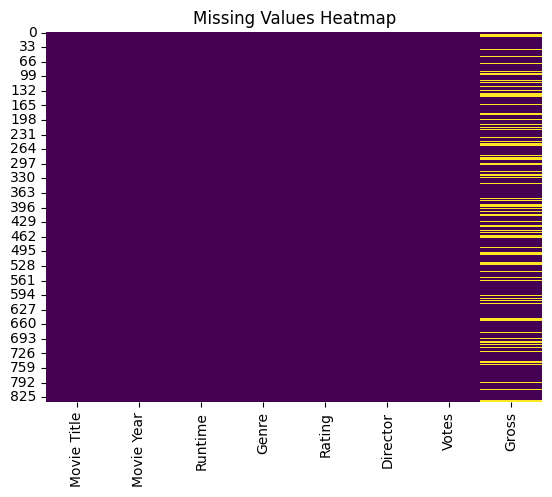

In [34]:
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title("Missing Values Heatmap")
plt.show()

In [35]:
categorical_cols = df.select_dtypes(include='object').columns
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts().head())


Column: Movie Title
Movie Title
Night of the Living Dead     2
A Nightmare on Elm Street    2
Frankenstein                 2
King Kong                    2
Carrie                       2
Name: count, dtype: int64

Column: Genre
Genre
Horror, Mystery, Thriller    98
Horror, Thriller             81
Drama, Horror, Mystery       71
Horror                       50
Drama, Fantasy, Horror       36
Name: count, dtype: int64

Column: Director
Director
Wes Craven            11
John Carpenter        11
David Cronenberg       8
Guillermo del Toro     7
James Wan              7
Name: count, dtype: int64

Column: Votes
Votes
98,740       2
68,040       2
35,242       2
6,89,068     1
10,51,582    1
Name: count, dtype: int64

Column: Gross
Gross
$0.02M    8
$0.08M    6
$0.01M    6
$0.05M    5
$0.03M    5
Name: count, dtype: int64


In [36]:
genre_grp = df.groupby(['Genre'])

filtered_df = genre_grp.filter(lambda x: len(x) >= 10)

                  Movie Title  Movie Year  Runtime                      Genre  \
0                       Alien        1979      117             Horror, Sci-Fi   
1                      Psycho        1960      109  Horror, Mystery, Thriller   
2                 The Shining        1980      146              Drama, Horror   
3                   The Thing        1982      109    Horror, Mystery, Sci-Fi   
4                     Tumbbad        2018      104     Drama, Fantasy, Horror   
..                        ...         ...      ...                        ...   
831                   Troll 2        1990       95    Comedy, Fantasy, Horror   
832                    Laxmii        2020      141     Action, Comedy, Horror   
833         Alone in the Dark        2005       96     Action, Horror, Sci-Fi   
834         House of the Dead        2003       90  Action, Adventure, Horror   
835  Manos: The Hands of Fate        1966       70                     Horror   

     Rating          Direct

In [ ]:
# 1. Dataset Selection:
#    My data set is an IMDB Horror Movie Dataset.  It contains categorical and numerical columns.  
#    I chose this dataset for my final project and I am using it here as well. 

# 2. Loading the Dataset:
#    Load the dataset into a Pandas DataFrame

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline
%reload_ext autoreload
%autoreload 2
df = pd.read_csv('/Notebooks/Datasets/Horror Movies IMDb.csv')

# 3. Exploratory Data Analysis:
#     Perform initial exploratory data analysis to understand the structure of the dataset, 
#     check for missing values, and get a general idea of the data distribution.

print(df.head())
print(df.info())
print(df.dtypes)
print(df.shape)
print(df.isnull().sum())

#This is a look at numerical distributions
print(df.describe())

# 4. Grouping and Aggregation:
#     Using the groupby function along with aggregation methods, perform the following tasks:
#     Calculate a summary statistic (e.g., mean, sum, count) for numerical columns within each group.

director_grp = df.groupby(['Director'])
director_grp.get_group('Wes Craven')
    #looking at the value counts per genre
director_grp['Genre'].value_counts().head(50)
        #or just look at value counts for a single director
director_grp['Genre'].value_counts().loc['Wes Craven']

genre_grp = df.groupby(['Genre'])

filtered_df = genre_grp.filter(lambda x: len(x) >= 10)

print(df['Genre'].value_counts())

print(filtered_df['Genre'].value_counts())
    # I filtered my genre column to only genres that have at least 10 movie titles associated.  

# 5. Filtering Data:
#     Apply filtering operations on the grouped data:

filt = df['Director'] == 'Wes Craven'
df.loc[filt]['Genre'].value_counts()

#     Filter out groups that meet specific conditions (e.g., exclude groups with a count below a certain threshold).
#     Make sure to note what you are excluding

filtered_df = genre_grp.filter(lambda x: len(x) >= 10)
    #I am filtering out movie genres that contain fewer than 10 films

# 6. Transforming Data:
#     Perform a data transformation within groups:
#     Create a new column containing a transformed value of a numerical column for a specific group

df['Genre_Rating_Zscore'] = df.groupby('Genre')['Rating'].transform(
    lambda x: (x - x.mean()) / x.std())
     # For each movie, it subtracts the mean rating of its genre and divides by the genre’s standard deviation.
     # The result is  z-score that shows how far above or below the genre average each movie is.
     # I can use this to identify standout scores within each genre, like my high performers and low performers:

    # Movies with exceptionally high ratings in their genre
high_performers = df[df['Genre_Rating_Zscore'] > 1.5]

# Movies with exceptionally low ratings in their genre
low_performers = df[df['Genre_Rating_Zscore'] < -1.5]

# I can turn this into a boxplot

plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Genre', y='Genre_Rating_Zscore')
plt.xticks(rotation=45)
plt.title("Distribution of Rating Z-Scores by Genre")
plt.show()

# This shows how ratings vary within each genre and helps spot genres with more consistent or more extreme ratings.


df['Normalized_Rating'] = df.groupby('Genre')['Rating'].transform(
    lambda x: (x - x.mean()) / x.std())
         # This Subtracts the mean rating of each genre from each movie’s rating.
         # It also divides by the standard deviation of that genre.
         # The result is a z-score that shows how each movie compares to others in its genre.

df['Rating_Rank_in_Genre'] = df.groupby('Genre')['Rating'].rank(ascending=False)
         # Assigns a rank to each movie based on its rating within its genre.
        # Rank 1 = highest rated movie in that genre.

df['Genre_Rank'] = df.groupby('Genre')['Rating'].rank(ascending=False)
        # This ranks movies by rating within their genre

# 8. Conclusion:
#     Summarize your findings from the aggregation, filtering, and transformation operations. 
#     What did you learn about your dataset? What challenges did you encounter?

In [51]:
df['Genre_Rank'] = df.groupby('Genre')['Rating'].rank(ascending=False)
        # This ranks movies by rating within their genre


In [47]:
filt = df['Director'] == 'Wes Craven'
df.loc[filt]['Genre'].value_counts()

Genre
Horror, Mystery             3
Comedy, Horror, Mystery     2
Horror                      1
Fantasy, Horror             1
Fantasy, Horror, Mystery    1
Horror, Thriller            1
Crime, Horror, Thriller     1
Comedy, Horror              1
Name: count, dtype: int64

In [40]:

director_grp = df.groupby(['Director'])
director_grp.get_group('Wes Craven')
    #looking at the value counts per genre
director_grp['Genre'].value_counts().head(50)
        #or just look at value counts for a single director


C:\Users\Administrator\AppData\Local\Temp\ipykernel_5256\396756668.py:2: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  director_grp.get_group('Wes Craven')


Director            Genre                     
Aaron Hann          Drama, Horror, Mystery        1
Adam Green          Comedy, Horror, Thriller      1
Adam Marcus         Fantasy, Horror, Thriller     1
Adam Robitel        Action, Adventure, Horror     2
                    Horror, Mystery, Thriller     2
Adam Wingard        Crime, Drama, Fantasy         1
                    Horror, Mystery, Thriller     1
                    Horror, Thriller              1
Adrian Lyne         Drama, Horror, Mystery        1
Alan Parker         Horror, Mystery, Thriller     1
Albert Hughes       Horror, Mystery, Thriller     1
Alejandro Amenábar  Adventure, Crime, Drama       1
                    Crime, Horror, Mystery        1
                    Horror, Mystery, Thriller     1
Alex Garland        Adventure, Drama, Horror      1
                    Drama, Fantasy, Horror        1
Alex Kurtzman       Action, Adventure, Fantasy    1
Alex Proyas         Action, Crime, Drama          1
Alexander Witt   

In [41]:
director_grp['Genre'].value_counts().loc['Wes Craven']

genre_grp = df.groupby(['Genre'])

filtered_df = genre_grp.filter(lambda x: len(x) >= 10)

In [46]:
print(filtered_df['Genre'].value_counts())


Genre
Horror, Mystery, Thriller     98
Horror, Thriller              81
Drama, Horror, Mystery        71
Horror                        50
Drama, Fantasy, Horror        36
Horror, Mystery               36
Action, Horror, Sci-Fi        34
Comedy, Horror                26
Comedy, Fantasy, Horror       24
Drama, Horror, Sci-Fi         22
Action, Adventure, Horror     21
Horror, Mystery, Sci-Fi       20
Horror, Sci-Fi, Thriller      19
Drama, Horror, Thriller       18
Horror, Sci-Fi                17
Crime, Drama, Horror          14
Action, Comedy, Horror        13
Fantasy, Horror               13
Action, Fantasy, Horror       13
Drama, Horror                 12
Fantasy, Horror, Mystery      11
Action, Adventure, Fantasy    11
Comedy, Horror, Thriller      10
Crime, Horror, Mystery        10
Name: count, dtype: int64


In [45]:
print(df['Genre'].value_counts())

Genre
Horror, Mystery, Thriller    98
Horror, Thriller             81
Drama, Horror, Mystery       71
Horror                       50
Drama, Fantasy, Horror       36
                             ..
Animation, Comedy, Family     1
Adventure, Crime, Drama       1
Fantasy, Horror, Sci-Fi       1
Action, Comedy, Drama         1
Action, Horror, War           1
Name: count, Length: 79, dtype: int64


In [52]:
df['Genre_Rating_Zscore'] = df.groupby('Genre')['Rating'].transform(
    lambda x: (x - x.mean()) / x.std())

In [53]:

    # Movies with exceptionally high ratings in their genre
high_performers = df[df['Genre_Rating_Zscore'] > 1.5]

# Movies with exceptionally low ratings in their genre
low_performers = df[df['Genre_Rating_Zscore'] < -1.5]




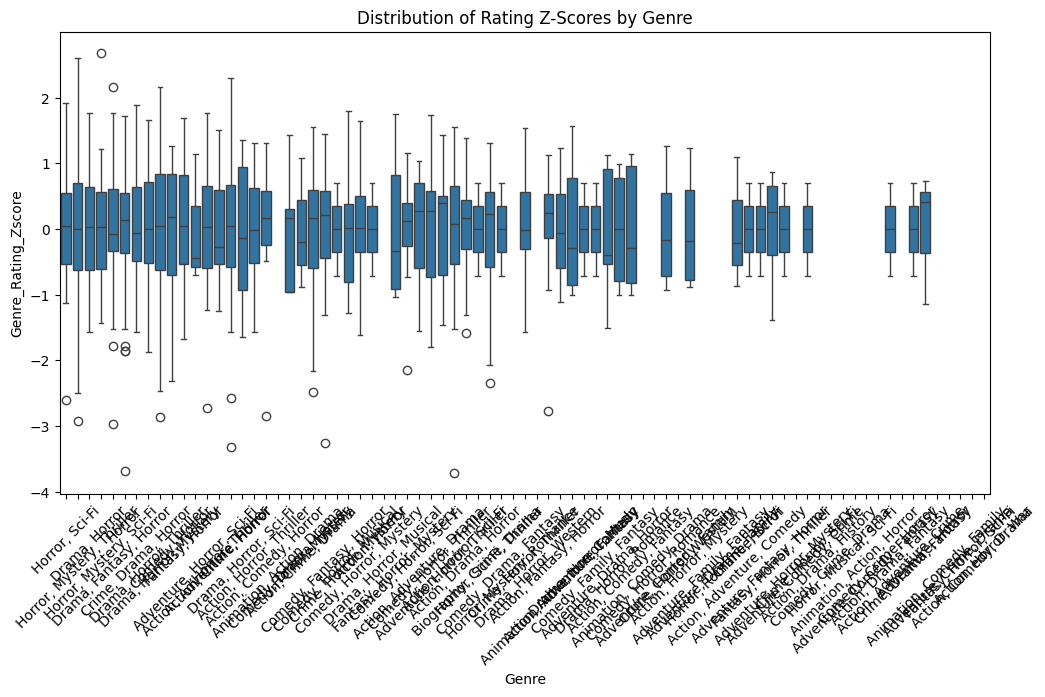

In [54]:
plt.figure(figsize=(12, 6))
sns.boxplot(data=df, x='Genre', y='Genre_Rating_Zscore')
plt.xticks(rotation=45)
plt.title("Distribution of Rating Z-Scores by Genre")
plt.show()


# This shows how ratings vary within each genre and helps spot genres with more consistent or more extreme ratings.